In [3]:
# Imports and device
from __future__ import annotations

import math
import os
import random
import re
import shutil
import time
from collections import Counter, OrderedDict, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import chess
import chess.engine
import chess.pgn
import chess.polyglot
import chess.svg

from IPython.display import SVG, clear_output, display

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("python-chess:", getattr(chess, "__version__", "unknown"))
print("torch:", torch.__version__)




# Paths and knobs
HOME = Path.home()
DOWNLOADS = HOME / "Downloads"
OUT_DIR = DOWNLOADS / "chess_play_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Your uploaded checkpoint. Change this if you move it.
WEIGHTS_PATH = Path(r"C:\\Users\\samue\\OneDrive\\Desktop\\projects\\ML\\chess-learn\\n6\\weights\\new_labels2.pth")

# Optional opening DB. Can be .npz with positions, .pgn, .txt/.uci/.san lines, or a polyglot .bin.
# Leave as None to auto-detect Games.npz in the current folder or Downloads.
OPENING_DB_PATH = None
OPENING_DB_MAX_GAMES = 100_000
OPENING_BOOK_PLIES = 12
OPENING_DB_PROGRESS_EVERY = 10_000

# Optional Stockfish binary. Leave as None to try PATH / common local names.
STOCKFISH_PATH = None

# Optional Syzygy tablebases. A 3-5 piece set is realistic on a laptop.
# Example: SYZYGY_PATH = r"D:\syzygy\3-4-5"
SYZYGY_PATH = None
ENABLE_SYZYGY = True
SYZYGY_MAX_PIECES = 5

# Value target in training was sigmoid(cp / 400), so raw model value * 400 ~= centipawns.
VALUE_CP_SCALE = 400.0

# Timed improved-search defaults.
DEFAULT_MODEL_TIME = 2.0
DEFAULT_MODEL_MAX_DEPTH = 8
DEFAULT_MODEL_MIN_DEPTH = 1
DEFAULT_STOCKFISH_DEPTH = 8
MAX_PLIES = 220
RANDOM_SEED = 7

# Search speed/strength knobs.
SEARCH_ROOT_TOP_N = 12
SEARCH_CHILD_TOP_N = 6
SEARCH_QUIESCENCE_DEPTH = 2
SEARCH_EXTENSION_LIMIT = 2
EVAL_CACHE_MAX_ITEMS = 200_000
TT_MAX_ITEMS = 500_000

# "Play to win" knobs.
DRAW_CONTEMPT_CP = 140.0
DRAW_CONTEMPT_TRIGGER_CP = 90.0
CONVERSION_TRIGGER_CP = 180.0
CONVERSION_MARGIN_CP = 90.0

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Weights:", WEIGHTS_PATH, "exists=", WEIGHTS_PATH.exists())
print("Output folder:", OUT_DIR)
print(f"Default model search: {DEFAULT_MODEL_TIME:.1f}s, max depth {DEFAULT_MODEL_MAX_DEPTH}")


Using device: cuda
python-chess: 1.10.0
torch: 2.0.1+cu117
Weights: C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n6\weights\new_labels2.pth exists= True
Output folder: C:\Users\samue\Downloads\chess_play_outputs
Default model search: 2.0s, max depth 8


In [7]:
# Clean FEN analyzer for the current NeuralChessPlayer.
# Usage:
#   report = analyze_fen("FEN HERE")
#   report = analyze_fen("FEN HERE", compare_moves=["Bxf7+", "d4"], seconds=30)

import time
import math
import numpy as np
import pandas as pd
import chess

try:
    from IPython.display import display
except Exception:
    display = print


def _ana_clear_deadline(p):
    if hasattr(p, "deadline"):
        p.deadline = None


def _ana_make_player(base=None, fresh=True):
    """
    Makes a separate clean analysis player so this does not inherit stale timeout state.
    If construction fails, it falls back to the existing player.
    """
    base = base or player
    if not fresh:
        _ana_clear_deadline(base)
        return base

    try:
        cls = base.__class__
        p = cls(
            getattr(base, "model", model),
            getattr(base, "device", device),
            cp_scale=getattr(base, "cp_scale", globals().get("VALUE_CP_SCALE", 400.0)),
            mate_score=getattr(base, "mate_score", 100_000.0),
            tt_max_items=getattr(base, "tt_max_items", globals().get("TT_MAX_ITEMS", 250_000)),
            eval_cache_max_items=getattr(base, "eval_cache_max_items", globals().get("EVAL_CACHE_MAX_ITEMS", 250_000)),
            root_top_n=getattr(base, "root_top_n", globals().get("SEARCH_ROOT_TOP_N", 12)),
            child_top_n=getattr(base, "child_top_n", globals().get("SEARCH_CHILD_TOP_N", 6)),
            q_depth=getattr(base, "q_depth", globals().get("SEARCH_QUIESCENCE_DEPTH", 2)),
            extension_limit=getattr(base, "extension_limit", globals().get("SEARCH_EXTENSION_LIMIT", 2)),
            draw_contempt_cp=getattr(base, "draw_contempt_cp", globals().get("DRAW_CONTEMPT_CP", 140)),
            draw_contempt_trigger_cp=getattr(base, "draw_contempt_trigger_cp", globals().get("DRAW_CONTEMPT_TRIGGER_CP", 250)),
            conversion_trigger_cp=getattr(base, "conversion_trigger_cp", globals().get("CONVERSION_TRIGGER_CP", 180)),
            conversion_margin_cp=getattr(base, "conversion_margin_cp", globals().get("CONVERSION_MARGIN_CP", 90)),
            syzygy_path=None,
            syzygy_max_pieces=getattr(base, "syzygy_max_pieces", globals().get("SYZYGY_MAX_PIECES", 7)),
        )
        if hasattr(p, "clear_caches"):
            p.clear_caches()
        _ana_clear_deadline(p)
        return p
    except Exception as exc:
        print("Could not create fresh analysis player, using existing player:", repr(exc))
        _ana_clear_deadline(base)
        return base


def _ana_eval_out_score(eval_out):
    if isinstance(eval_out, tuple):
        return eval_out[0], eval_out[1] if len(eval_out) > 1 else None
    return eval_out, None


def _ana_eval_white(p, board):
    """
    Returns eval in centipawns from White's perspective.
    This matches your search code: White maximizes, Black minimizes.
    """
    _ana_clear_deadline(p)

    if hasattr(p, "terminal_value"):
        try:
            tv = p.terminal_value(board)
            if tv is not None:
                return float(tv), None
        except Exception:
            pass

    out = p.evaluate(board)
    _ana_clear_deadline(p)

    score, logits = _ana_eval_out_score(out)
    return float(score), logits


def _ana_side_score(board, white_cp):
    return float(white_cp) if board.turn == chess.WHITE else -float(white_cp)


def _ana_score_for_color(color, white_cp):
    return float(white_cp) if color == chess.WHITE else -float(white_cp)


def _ana_result_fields(res):
    if res is None:
        return {
            "move": None,
            "score_cp": None,
            "source": None,
            "depth": None,
            "nodes": None,
            "elapsed": None,
            "candidates": [],
        }

    if isinstance(res, dict):
        return {
            "move": res.get("move"),
            "score_cp": res.get("score_cp", res.get("score", res.get("eval"))),
            "source": res.get("source"),
            "depth": res.get("depth"),
            "nodes": res.get("nodes"),
            "elapsed": res.get("elapsed"),
            "candidates": res.get("candidates") or [],
        }

    return {
        "move": getattr(res, "move", None),
        "score_cp": getattr(res, "score_cp", getattr(res, "score", None)),
        "source": getattr(res, "source", None),
        "depth": getattr(res, "depth", None),
        "nodes": getattr(res, "nodes", None),
        "elapsed": getattr(res, "elapsed", None),
        "candidates": getattr(res, "candidates", None) or [],
    }


def _ana_run_choose(
    p,
    board,
    seconds=None,
    max_depth=None,
    fixed_depth=None,
    min_depth=1,
    top_k=1,
    temperature_cp=0.0,
):
    _ana_clear_deadline(p)

    if max_depth is None:
        max_depth = globals().get("DEFAULT_MODEL_MAX_DEPTH", 8)

    if fixed_depth is not None:
        res = p.choose_move(
            board.copy(stack=True),
            depth=int(fixed_depth),
            time_limit=None,
            max_depth=int(fixed_depth),
            min_depth=int(fixed_depth),
            top_k=top_k,
            temperature_cp=temperature_cp,
            verbose=False,
        )
    else:
        res = p.choose_move(
            board.copy(stack=True),
            depth=None,
            time_limit=float(seconds) if seconds is not None else 30.0,
            max_depth=int(max_depth),
            min_depth=int(min_depth),
            top_k=top_k,
            temperature_cp=temperature_cp,
            verbose=False,
        )

    _ana_clear_deadline(p)
    return res


def _ana_parse_move(board, move_text):
    if isinstance(move_text, chess.Move):
        if move_text in board.legal_moves:
            return move_text
        raise ValueError(f"Illegal move: {move_text}")

    s = str(move_text).strip()

    try:
        mv = board.parse_san(s)
        if mv in board.legal_moves:
            return mv
    except Exception:
        pass

    try:
        mv = chess.Move.from_uci(s)
        if mv in board.legal_moves:
            return mv
    except Exception:
        pass

    legal = []
    for mv in board.legal_moves:
        legal.append(board.san(mv))

    raise ValueError(f"Could not parse legal move {move_text!r}. Legal SAN moves include: {legal[:30]}")


def _ana_move_notes(board, move):
    notes = []

    if board.is_capture(move):
        attacker = board.piece_at(move.from_square)
        victim = None

        if board.is_en_passant(move):
            victim = chess.Piece(chess.PAWN, not board.turn)
        else:
            victim = board.piece_at(move.to_square)

        if attacker and victim:
            notes.append(f"{chess.piece_name(attacker.piece_type)}x{chess.piece_name(victim.piece_type)}")
        else:
            notes.append("capture")

    if move.promotion:
        notes.append("promotes=" + chess.piece_name(move.promotion))

    if board.gives_check(move):
        b = board.copy(stack=False)
        b.push(move)
        notes.append("mate" if b.is_checkmate() else "check")

    return ", ".join(notes)


def _ana_policy_table(p, board, top_n=20):
    static_cp, logits = _ana_eval_white(p, board)

    rows = []
    for mv in board.legal_moves:
        logit = np.nan
        if logits is not None and "move_to_index" in globals():
            try:
                idx = move_to_index(mv)
                if 0 <= idx < len(logits) and np.isfinite(logits[idx]):
                    logit = float(logits[idx])
            except Exception:
                pass

        rows.append({
            "move_obj": mv,
            "move": board.san(mv),
            "uci": mv.uci(),
            "policy_logit": logit,
            "notes": _ana_move_notes(board, mv),
        })

    if not rows:
        return pd.DataFrame(), {}

    finite = np.array([
        r["policy_logit"] if np.isfinite(r["policy_logit"]) else -1e9
        for r in rows
    ], dtype=np.float64)

    if np.all(finite <= -1e8):
        probs = np.ones(len(rows), dtype=np.float64) / max(1, len(rows))
    else:
        exps = np.exp(finite - np.max(finite))
        probs = exps / np.sum(exps)

    for r, prob in zip(rows, probs):
        r["policy_prob"] = float(prob)

    rows.sort(key=lambda r: r["policy_logit"] if np.isfinite(r["policy_logit"]) else -1e9, reverse=True)

    policy_map = {}
    for rank, r in enumerate(rows, start=1):
        r["policy_rank"] = rank
        policy_map[r["uci"]] = {
            "policy_rank": rank,
            "policy_logit": r["policy_logit"],
            "policy_prob": r["policy_prob"],
        }

    df = pd.DataFrame(rows)
    df = df[["policy_rank", "move", "uci", "policy_prob", "policy_logit", "notes"]]
    return df.head(top_n), policy_map


def _ana_candidate_table(p, board, candidates, policy_map=None):
    policy_map = policy_map or {}
    root_turn = board.turn

    clean = []
    for item in candidates or []:
        if isinstance(item, tuple) and len(item) >= 2:
            score, mv = item[0], item[1]
        elif isinstance(item, dict):
            score, mv = item.get("score_cp", item.get("score")), item.get("move")
        else:
            score, mv = getattr(item, "score_cp", getattr(item, "score", None)), getattr(item, "move", None)

        if isinstance(mv, str):
            mv = _ana_parse_move(board, mv)

        if mv is None or mv not in board.legal_moves:
            continue

        clean.append((float(score), mv))

    if not clean:
        return pd.DataFrame(), {}

    clean.sort(key=lambda x: _ana_score_for_color(root_turn, x[0]), reverse=True)
    best_side = _ana_score_for_color(root_turn, clean[0][0])

    rows = []
    score_by_uci = {}

    for rank, (score, mv) in enumerate(clean, start=1):
        side_score = _ana_score_for_color(root_turn, score)
        pol = policy_map.get(mv.uci(), {})

        conv = None
        if hasattr(p, "conversion_score"):
            try:
                conv = p.conversion_score(board, mv, score, root_turn)
            except Exception:
                conv = None

        rows.append({
            "rank_by_search": rank,
            "move": board.san(mv),
            "uci": mv.uci(),
            "search_cp_white": score,
            "search_cp_for_side": side_score,
            "delta_from_best_side_cp": best_side - side_score,
            "policy_rank": pol.get("policy_rank"),
            "policy_prob": pol.get("policy_prob"),
            "policy_logit": pol.get("policy_logit"),
            "conversion_score": conv,
            "notes": _ana_move_notes(board, mv),
        })
        score_by_uci[mv.uci()] = score

    return pd.DataFrame(rows), score_by_uci


def _ana_depth_table(p, board, max_depth, policy_map=None):
    policy_map = policy_map or {}
    rows = []

    for d in range(1, int(max_depth) + 1):
        start = time.perf_counter()
        try:
            res = _ana_run_choose(p, board, fixed_depth=d)
            f = _ana_result_fields(res)
            mv = f["move"]

            if mv is None or mv not in board.legal_moves:
                rows.append({"depth": d, "error": "no legal move returned"})
                continue

            score = float(f["score_cp"])
            pol = policy_map.get(mv.uci(), {})

            rows.append({
                "depth": d,
                "move": board.san(mv),
                "uci": mv.uci(),
                "cp_white": score,
                "cp_for_side": _ana_score_for_color(board.turn, score),
                "policy_rank": pol.get("policy_rank"),
                "policy_prob": pol.get("policy_prob"),
                "source": f["source"],
                "nodes": f["nodes"],
                "elapsed": f["elapsed"] if f["elapsed"] is not None else time.perf_counter() - start,
                "notes": _ana_move_notes(board, mv),
            })
        except Exception as exc:
            rows.append({"depth": d, "error": repr(exc)})
            break

    return pd.DataFrame(rows)


def _ana_build_line(
    p,
    board,
    plies,
    original_turn,
    first_move=None,
    first_result=None,
    forced_score_cp=None,
    first_source="forced",
):
    """
    Reconstructs the expected line in the style of your search:
    best move, best reply, best move, best reply...
    """
    b = board.copy(stack=True)
    rows = []

    for step in range(int(plies)):
        if b.is_game_over(claim_draw=True):
            break

        remaining_depth = max(1, int(plies) - step)

        if step == 0 and first_move is not None:
            mv = first_move
            f = _ana_result_fields(first_result)
            search_cp = forced_score_cp if forced_score_cp is not None else f["score_cp"]
            source = f["source"] if f["source"] is not None else first_source
            searched_depth = f["depth"]
            nodes = f["nodes"]
            elapsed = f["elapsed"]
        else:
            res = _ana_run_choose(p, b, fixed_depth=remaining_depth)
            f = _ana_result_fields(res)
            mv = f["move"]
            search_cp = f["score_cp"]
            source = f["source"]
            searched_depth = f["depth"]
            nodes = f["nodes"]
            elapsed = f["elapsed"]

        if mv is None or mv not in b.legal_moves:
            break

        static_before, _ = _ana_eval_white(p, b)
        san = b.san(mv)
        notes = _ana_move_notes(b, mv)

        b.push(mv)

        static_after, _ = _ana_eval_white(p, b)

        rows.append({
            "line_step": step + 1,
            "side_to_move": "White" if not b.turn == chess.WHITE else "Black",
            "move": san,
            "uci": mv.uci(),
            "remaining_depth_requested": remaining_depth,
            "searched_depth": searched_depth,
            "search_cp_white": search_cp,
            "search_cp_for_original_side": None if search_cp is None else _ana_score_for_color(original_turn, search_cp),
            "static_before_cp_white": static_before,
            "static_after_cp_white": static_after,
            "static_after_cp_for_original_side": _ana_score_for_color(original_turn, static_after),
            "source": source,
            "nodes": nodes,
            "elapsed": elapsed,
            "notes": notes,
            "fen_after": b.fen(),
        })

    df = pd.DataFrame(rows)
    return df, b


def _ana_line_summary(df, final_board, root_score_cp, original_turn):
    if df is None or len(df) == 0:
        return {
            "line": "",
            "root_search_cp_white": root_score_cp,
            "root_search_cp_for_original_side": None if root_score_cp is None else _ana_score_for_color(original_turn, root_score_cp),
            "final_static_cp_white": None,
            "final_static_cp_for_original_side": None,
            "final_fen": final_board.fen(),
        }

    final_static = df.iloc[-1]["static_after_cp_white"]

    return {
        "line": " ".join(df["move"].astype(str).tolist()),
        "root_search_cp_white": root_score_cp,
        "root_search_cp_for_original_side": None if root_score_cp is None else _ana_score_for_color(original_turn, root_score_cp),
        "final_static_cp_white": final_static,
        "final_static_cp_for_original_side": _ana_score_for_color(original_turn, final_static),
        "final_fen": final_board.fen(),
    }


def _ana_compare_forced_moves(
    p,
    board,
    compare_moves,
    seconds,
    max_depth,
    root_score_by_uci,
    original_turn,
    show_details=True,
):
    summaries = []
    details = {}

    for move_text in compare_moves:
        mv = _ana_parse_move(board, move_text)
        forced_san = board.san(mv)
        forced_score = root_score_by_uci.get(mv.uci())

        b = board.copy(stack=True)
        static_before, _ = _ana_eval_white(p, b)
        notes = _ana_move_notes(b, mv)
        b.push(mv)
        static_after, _ = _ana_eval_white(p, b)

        forced_row = pd.DataFrame([{
            "line_step": 1,
            "side_to_move": "White" if original_turn == chess.WHITE else "Black",
            "move": forced_san,
            "uci": mv.uci(),
            "remaining_depth_requested": None,
            "searched_depth": None,
            "search_cp_white": forced_score,
            "search_cp_for_original_side": None if forced_score is None else _ana_score_for_color(original_turn, forced_score),
            "static_before_cp_white": static_before,
            "static_after_cp_white": static_after,
            "static_after_cp_for_original_side": _ana_score_for_color(original_turn, static_after),
            "source": "forced-by-user",
            "nodes": None,
            "elapsed": None,
            "notes": notes,
            "fen_after": b.fen(),
        }])

        if b.is_game_over(claim_draw=True):
            full_df = forced_row
            final_board = b
            reply_depth = 0
            reply_score = static_after
        else:
            reply_res = _ana_run_choose(p, b, seconds=seconds, max_depth=max_depth)
            rf = _ana_result_fields(reply_res)
            reply_depth = int(rf["depth"] or 1)
            reply_score = rf["score_cp"]

            reply_df, final_board = _ana_build_line(
                p,
                b,
                plies=max(1, reply_depth),
                original_turn=original_turn,
                first_move=rf["move"],
                first_result=reply_res,
                forced_score_cp=reply_score,
                first_source="full-search-reply",
            )

            if len(reply_df):
                reply_df = reply_df.copy()
                reply_df["line_step"] = reply_df["line_step"] + 1
                full_df = pd.concat([forced_row, reply_df], ignore_index=True)
            else:
                full_df = forced_row
                final_board = b

        final_static = full_df.iloc[-1]["static_after_cp_white"]

        summaries.append({
            "forced_move": forced_san,
            "uci": mv.uci(),
            "was_in_root_candidates": forced_score is not None,
            "root_candidate_cp_white": forced_score,
            "root_candidate_cp_for_original_side": None if forced_score is None else _ana_score_for_color(original_turn, forced_score),
            "opponent_full_search_depth": reply_depth,
            "opponent_full_search_cp_white": reply_score,
            "opponent_full_search_cp_for_original_side": None if reply_score is None else _ana_score_for_color(original_turn, reply_score),
            "final_static_cp_white": final_static,
            "final_static_cp_for_original_side": _ana_score_for_color(original_turn, final_static),
            "line": " ".join(full_df["move"].astype(str).tolist()),
            "final_fen": final_board.fen(),
        })

        details[forced_san] = full_df

        if show_details:
            print()
            print("=" * 100)
            print(f"FORCED MOVE ANALYSIS: {forced_san}")
            print("=" * 100)
            display(full_df)

    return pd.DataFrame(summaries), details


def analyze_fen(
    fen,
    seconds=30.0,
    max_depth=None,
    top_n=10,
    candidate_lines=5,
    line_depth=None,
    compare_moves=None,
    fresh_player=True,
    show_board=True,
    show_forced_details=True,
):
    """
    Main function.

    fen:
        Position to analyze.

    seconds:
        Time for the main recommendation search. Default 30s.

    max_depth:
        Max search depth. Defaults to DEFAULT_MODEL_MAX_DEPTH.

    candidate_lines:
        How many root candidate lines to reconstruct.

    compare_moves:
        Optional list of SAN or UCI moves.
        Example: compare_moves=["Bxf7+", "d4", "Qh5"]

        For each forced move, the function lets the opponent run a full
        seconds-long search from the resulting position, then reconstructs
        the expected continuation.
    """
    if max_depth is None:
        max_depth = globals().get("DEFAULT_MODEL_MAX_DEPTH", 8)

    board = chess.Board(fen)
    original_turn = board.turn
    p = _ana_make_player(fresh=fresh_player)

    print("=" * 100)
    print("FEN ANALYSIS")
    print("=" * 100)
    print("FEN:", board.fen())
    print("Side to move:", "White" if board.turn == chess.WHITE else "Black")
    print(f"Main search: {seconds:.1f}s, max depth {max_depth}")

    if show_board:
        display(board)

    static_cp, _ = _ana_eval_white(p, board)
    print(f"Static NN eval: {static_cp:+.1f} cp from White")
    print(f"Static NN eval: {_ana_score_for_color(original_turn, static_cp):+.1f} cp for side to move")

    print()
    print("=" * 100)
    print("POLICY HEAD TOP MOVES")
    print("=" * 100)
    policy_df, policy_map = _ana_policy_table(p, board, top_n=top_n)
    display(policy_df)

    print()
    print("=" * 100)
    print("MAIN 30s SEARCH")
    print("=" * 100)
    root_res = _ana_run_choose(p, board, seconds=seconds, max_depth=max_depth)
    root = _ana_result_fields(root_res)

    if root["move"] is None:
        print("No move returned.")
        return None

    root_san = board.san(root["move"])
    print(f"Recommended move: {root_san}")
    print(f"Source: {root['source']}")
    print(f"Completed depth: {root['depth']}")
    print(f"Nodes: {root['nodes']}")
    print(f"Elapsed: {root['elapsed']:.3f}s" if root["elapsed"] is not None else "Elapsed: ?")
    print(f"Search eval: {root['score_cp']:+.1f} cp from White")
    print(f"Search eval: {_ana_score_for_color(original_turn, root['score_cp']):+.1f} cp for side to move")

    candidate_df, root_score_by_uci = _ana_candidate_table(p, board, root["candidates"], policy_map)

    print()
    print("=" * 100)
    print("ROOT MOVES COMPARED BY SEARCH")
    print("=" * 100)
    display(candidate_df.head(top_n))

    completed_depth = int(root["depth"] or 1)

    print()
    print("=" * 100)
    print("DEPTH-BY-DEPTH RECOMMENDATION")
    print("=" * 100)
    depth_df = _ana_depth_table(p, board, completed_depth, policy_map)
    display(depth_df)

    use_line_depth = int(line_depth or completed_depth)

    print()
    print("=" * 100)
    print("EXPECTED LINE FOR RECOMMENDED MOVE")
    print("=" * 100)
    chosen_line_df, chosen_final_board = _ana_build_line(
        p,
        board,
        plies=use_line_depth,
        original_turn=original_turn,
        first_move=root["move"],
        first_result=root_res,
        forced_score_cp=root["score_cp"],
        first_source="main-search",
    )
    display(chosen_line_df)

    print()
    print("Expected line:")
    if len(chosen_line_df):
        print(" ".join(chosen_line_df["move"].astype(str).tolist()))
        print("Final FEN:", chosen_final_board.fen())

    print()
    print("=" * 100)
    print("FULL LINE COMPARISON FOR TOP ROOT CANDIDATES")
    print("=" * 100)

    line_summaries = []
    line_details = {}

    if len(candidate_df):
        for _, row in candidate_df.head(candidate_lines).iterrows():
            mv = chess.Move.from_uci(row["uci"])
            root_score = float(row["search_cp_white"])

            line_df, final_board = _ana_build_line(
                p,
                board,
                plies=use_line_depth,
                original_turn=original_turn,
                first_move=mv,
                first_result=None,
                forced_score_cp=root_score,
                first_source="root-candidate",
            )

            summary = _ana_line_summary(line_df, final_board, root_score, original_turn)
            summary["root_rank"] = int(row["rank_by_search"])
            summary["root_move"] = row["move"]
            summary["root_delta_from_best_side_cp"] = row["delta_from_best_side_cp"]
            line_summaries.append(summary)
            line_details[row["move"]] = line_df

    line_summary_df = pd.DataFrame(line_summaries)
    if len(line_summary_df):
        cols = [
            "root_rank",
            "root_move",
            "root_search_cp_white",
            "root_search_cp_for_original_side",
            "root_delta_from_best_side_cp",
            "final_static_cp_white",
            "final_static_cp_for_original_side",
            "line",
            "final_fen",
        ]
        display(line_summary_df[cols])

    forced_summary_df = pd.DataFrame()
    forced_details = {}

    if compare_moves:
        print()
        print("=" * 100)
        print("USER-FORCED MOVE COMPARISON")
        print("=" * 100)
        print(f"Each forced move gets opponent full search: {seconds:.1f}s, max depth {max_depth}")

        forced_summary_df, forced_details = _ana_compare_forced_moves(
            p,
            board,
            compare_moves=compare_moves,
            seconds=seconds,
            max_depth=max_depth,
            root_score_by_uci=root_score_by_uci,
            original_turn=original_turn,
            show_details=show_forced_details,
        )

        print()
        print("=" * 100)
        print("FORCED MOVE SUMMARY")
        print("=" * 100)
        display(forced_summary_df)

    return {
        "fen": fen,
        "board": board,
        "analysis_player": p,
        "static_cp_white": static_cp,
        "policy": policy_df,
        "root_result": root_res,
        "root_candidates": candidate_df,
        "depth_table": depth_df,
        "chosen_line": chosen_line_df,
        "chosen_final_board": chosen_final_board,
        "candidate_line_summary": line_summary_df,
        "candidate_line_details": line_details,
        "forced_summary": forced_summary_df,
        "forced_details": forced_details,
    }

Using: C:\Users\samue\Downloads\chess_play_outputs\new_instrumented_selfplay_20260701_030520.jsonl
Loaded records: 178

Largest candidate-choice losses:
ply  80 Black h5       src=nn             d=4 root0=  -61.5 depth= +474.8 diff_side= -536.3 loss= +382.4 best=Qd5 why=large disagreement with best sampled candidate
ply  62 Black Qd3      src=nn             d=4 root0= -341.9 depth=  -40.1 diff_side= -301.8 loss= +281.7 best=Be4 why=large disagreement with best sampled candidate
ply  82 Black Qg4+     src=nn             d=5 root0= +133.5 depth= +469.0 diff_side= -335.4 loss= +219.1 best=Qf3 why=large disagreement with best sampled candidate ; policy liked it most
ply   7 White Ba4      src=book           d=0 root0= +118.5 depth=   -9.9 diff_side= -128.4 loss= +180.2 best=Bxc6 why=book move
ply   9 White O-O      src=book           d=0 root0=  +53.2 depth=  -64.6 diff_side= -117.8 loss= +164.2 best=Bxc6 why=book move
ply  76 Black Qd1+     src=nn             d=4 root0=  -50.3 depth= +211

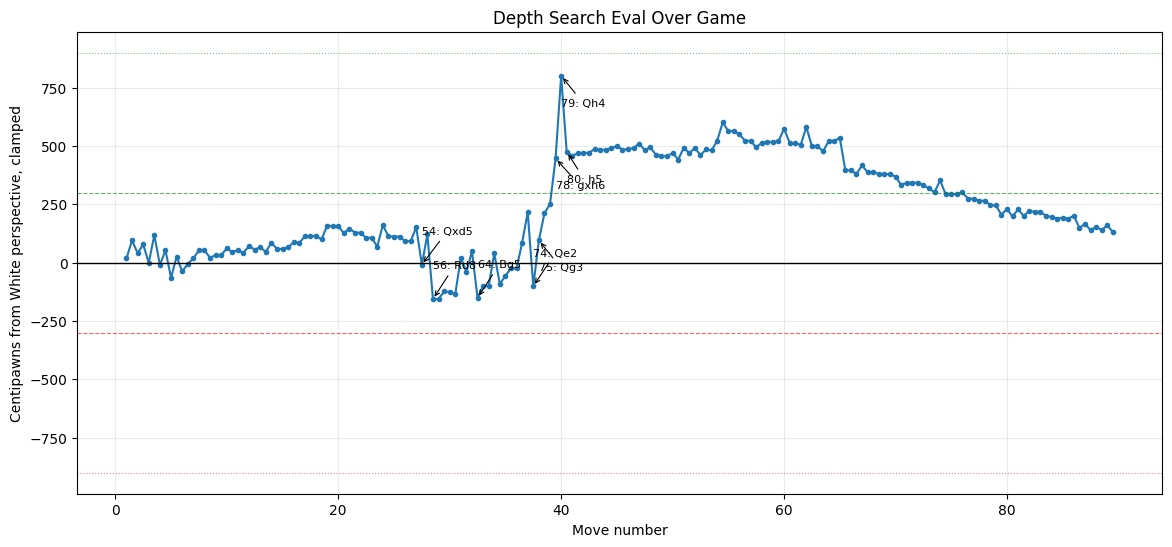

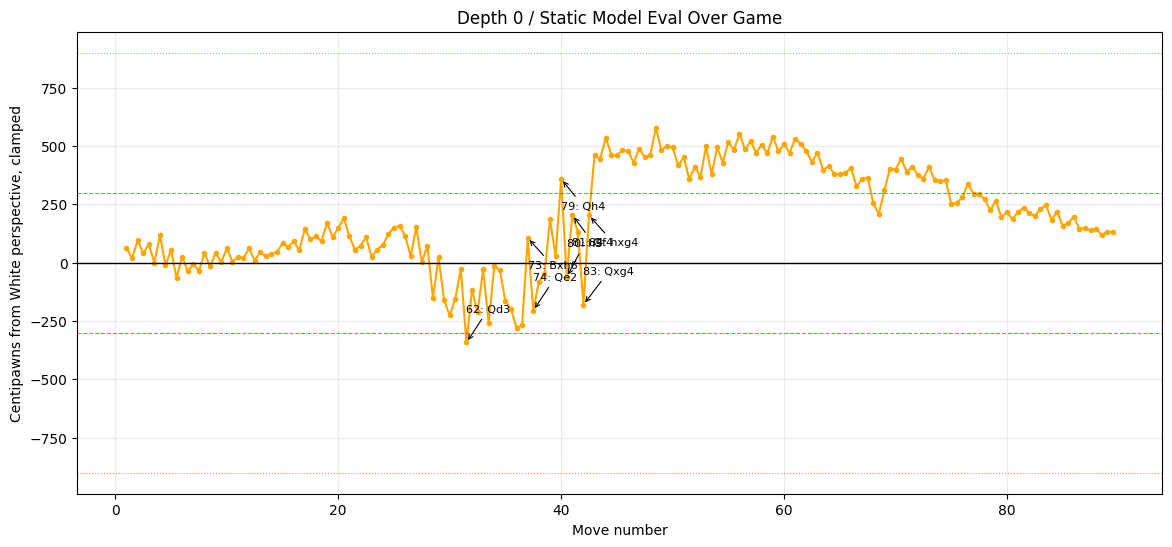

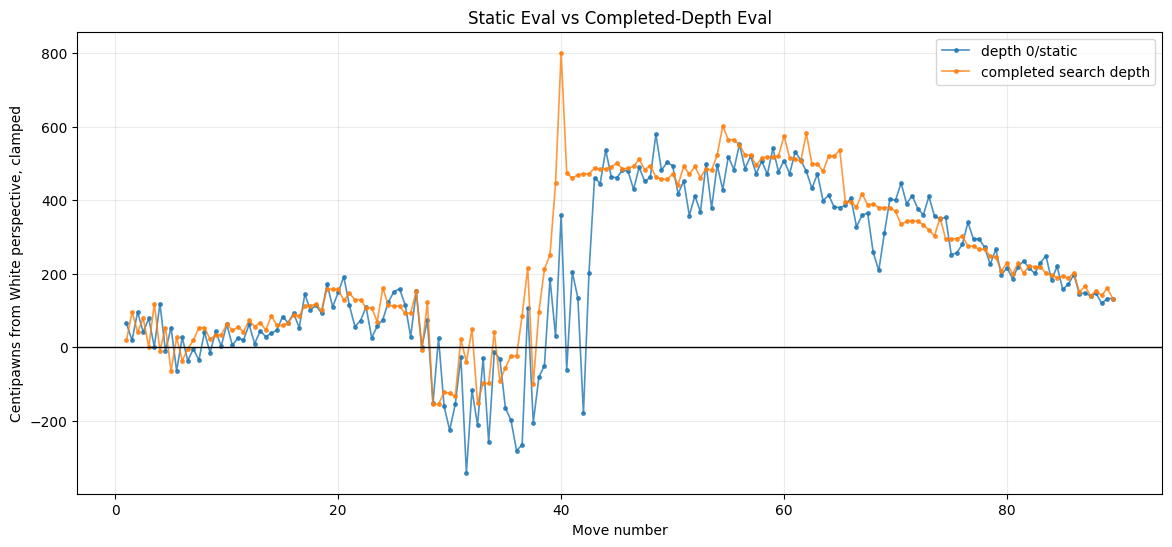


Helper: inspect_ply(28) to deep-dive a move.


In [4]:

# Analyze latest new-version instrumented self-play log and graph evals.
# Run after the self-play cell above, or just run it later to load the latest JSONL.

import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ANALYSIS_DIR = OUT_DIR

files = sorted(
    list(ANALYSIS_DIR.glob("new_instrumented_selfplay_*.jsonl")),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)

if not files:
    raise FileNotFoundError(f"No new_instrumented_selfplay_*.jsonl files found in {ANALYSIS_DIR}")

jsonl_path = files[0]
print("Using:", jsonl_path)

records = []
with jsonl_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print("Loaded records:", len(records))


def acp(x, clamp=2000):
    if x is None:
        return np.nan
    x = float(x)
    return max(-clamp, min(clamp, x))


def fmt_cp(x):
    if x is None:
        return "   ?   "
    return f"{float(x):+7.1f}"


def move_x(r):
    return (int(r["ply"]) + 1) / 2


def rec_loss(r):
    x = r.get("chosen_loss_vs_best_for_side_cp")
    return -999 if x is None else float(x)


def rec_abs_depth_diff(r):
    return abs(float(r.get("depth_minus_root_for_side", 0.0)))


def print_row(r):
    print(
        f"ply {r['ply']:>3} {r['side_to_move']:5s} {r['chosen_san']:8s} "
        f"src={r['source']:14s} d={r['completed_depth']} "
        f"root0={fmt_cp(r['root_static_cp_white'])} "
        f"depth={fmt_cp(r['depth_eval_cp_white'])} "
        f"diff_side={fmt_cp(r['depth_minus_root_for_side'])} "
        f"loss={fmt_cp(r.get('chosen_loss_vs_best_for_side_cp'))} "
        f"best={r.get('best_candidate_san')} "
        f"why={' ; '.join(r.get('why', []))}"
    )


def inspect_ply(ply, top_n=12):
    r = next(r for r in records if int(r["ply"]) == int(ply))
    print("=" * 110)
    print_row(r)
    print("FEN:", r["fen_before"])
    print("Recent moves:", " ".join(r.get("san_history_before", [])[-20:]))
    print("\nCandidates:")
    for c in r["candidates"][:top_n]:
        star = "*" if c["chosen"] else " "
        print(
            f"{c['rank_by_main_score']:>2}. {c['san']:8s}{star} "
            f"loss={fmt_cp(c['loss_vs_best_for_side_cp'])} "
            f"white={fmt_cp(c['main_score_cp_white'])} "
            f"side={fmt_cp(c['main_score_for_side'])} "
            f"static_after={fmt_cp(c['static_after_cp_white'])} "
            f"search={fmt_cp(c.get('search_score_cp_white'))} "
            f"policy=#{c.get('policy_rank')} "
            f"conv={c.get('conversion_score')} "
            f"flags={c.get('flags')}"
        )
    chosen = next((c for c in r["candidates"] if c["chosen"]), None)
    if chosen:
        print("\nReply probes after chosen move:")
        for rp in chosen.get("reply_probe", []):
            print(
                f"  {rp['san']:8s} "
                f"white={fmt_cp(rp['eval_after_reply_cp_white'])} "
                f"for_original_side={fmt_cp(rp['eval_after_reply_for_original_side'])} "
                f"flags={rp['flags']}"
            )
    return None


print("\nLargest candidate-choice losses:")
for r in sorted(records, key=rec_loss, reverse=True)[:20]:
    print_row(r)

print("\nLargest depth-search vs static disagreements:")
for r in sorted(records, key=rec_abs_depth_diff, reverse=True)[:20]:
    print_row(r)

print("\nConversion/mate/book source counts:")
counts = {}
for r in records:
    counts[r["source"]] = counts.get(r["source"], 0) + 1
for k, v in sorted(counts.items(), key=lambda x: x[0]):
    print(f"{k:18s}: {v}")


# Graph 1: what it thinks after the completed search depth.
x = [move_x(r) for r in records]
depth_eval = [acp(r.get("depth_eval_cp_white")) for r in records]
root_eval = [acp(r.get("root_static_cp_white")) for r in records]

plt.figure(figsize=(14, 6))
plt.plot(x, depth_eval, marker="o", linewidth=1.5, markersize=3)
plt.axhline(0, color="black", linewidth=1)
plt.axhline(300, color="green", linestyle="--", linewidth=0.8, alpha=0.6)
plt.axhline(-300, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
plt.axhline(900, color="green", linestyle=":", linewidth=0.8, alpha=0.5)
plt.axhline(-900, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
plt.title("Depth Search Eval Over Game")
plt.xlabel("Move number")
plt.ylabel("Centipawns from White perspective, clamped")
plt.grid(True, alpha=0.25)

swings = []
for i in range(1, len(depth_eval)):
    if np.isfinite(depth_eval[i]) and np.isfinite(depth_eval[i - 1]):
        swings.append((abs(depth_eval[i] - depth_eval[i - 1]), i))
for swing, i in sorted(swings, reverse=True)[:8]:
    r = records[i]
    plt.annotate(
        f"{r['ply']}: {r['chosen_san']}",
        xy=(x[i], depth_eval[i]),
        xytext=(x[i], depth_eval[i] + (130 if depth_eval[i] < 0 else -130)),
        arrowprops=dict(arrowstyle="->", lw=0.8),
        fontsize=8,
    )
plt.show()


# Graph 2: depth-0/static eval before each move.
plt.figure(figsize=(14, 6))
plt.plot(x, root_eval, marker="o", linewidth=1.5, markersize=3, color="orange")
plt.axhline(0, color="black", linewidth=1)
plt.axhline(300, color="green", linestyle="--", linewidth=0.8, alpha=0.6)
plt.axhline(-300, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
plt.axhline(900, color="green", linestyle=":", linewidth=0.8, alpha=0.5)
plt.axhline(-900, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
plt.title("Depth 0 / Static Model Eval Over Game")
plt.xlabel("Move number")
plt.ylabel("Centipawns from White perspective, clamped")
plt.grid(True, alpha=0.25)

swings0 = []
for i in range(1, len(root_eval)):
    if np.isfinite(root_eval[i]) and np.isfinite(root_eval[i - 1]):
        swings0.append((abs(root_eval[i] - root_eval[i - 1]), i))
for swing, i in sorted(swings0, reverse=True)[:8]:
    r = records[i]
    plt.annotate(
        f"{r['ply']}: {r['chosen_san']}",
        xy=(x[i], root_eval[i]),
        xytext=(x[i], root_eval[i] + (130 if root_eval[i] < 0 else -130)),
        arrowprops=dict(arrowstyle="->", lw=0.8),
        fontsize=8,
    )
plt.show()


# Optional overlay for comparing static vs search directly.
plt.figure(figsize=(14, 6))
plt.plot(x, root_eval, marker="o", linewidth=1.2, markersize=2.5, label="depth 0/static", alpha=0.8)
plt.plot(x, depth_eval, marker="o", linewidth=1.2, markersize=2.5, label="completed search depth", alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.title("Static Eval vs Completed-Depth Eval")
plt.xlabel("Move number")
plt.ylabel("Centipawns from White perspective, clamped")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("\nHelper: inspect_ply(28) to deep-dive a move.")


In [5]:
inspect_ply(24)

ply  24 Black Re8      src=nn             d=3 root0=   +9.5 depth=  +55.9 diff_side=  -46.4 loss=   +7.3 best=Qe8 why=chosen was basically tied with best
FEN: r1bq1rk1/2p1bpp1/2np1n1p/p3p3/Pp1PP3/1BP1BN1P/1P3PP1/RN1QR1K1 b - - 1 12
Recent moves: Nc6 Bb5 a6 Ba4 Nf6 O-O Be7 Re1 b5 Bb3 d6 h3 O-O c3 a5 a4 b4 d4 h6 Be3

Candidates:
 1. Qe8       loss=   +0.0 white=  +48.6 side=  -48.6 static_after=  +48.6 search=   ?    policy=#13 conv=-36.673268432617185 flags=[]
 2. Re8     * loss=   +7.3 white=  +55.9 side=  -55.9 static_after=  +44.0 search=  +55.9 policy=#5 conv=-38.42412281036377 flags=[]
 3. Bd7       loss=   +8.3 white=  +57.0 side=  -57.0 static_after=  +43.3 search=  +57.0 policy=#12 conv=-38.6756067276001 flags=[]
 4. Nd7       loss=   +8.7 white=  +57.3 side=  -57.3 static_after=  +57.3 search=   ?    policy=#14 conv=-38.75312316894531 flags=[]
 5. Ra6       loss=   +9.3 white=  +58.0 side=  -58.0 static_after=  +58.0 search=   ?    policy=#15 conv=-38.90866027832031 flags=[]
 6

In [6]:
inspect_ply(30)

ply  30 Black Nfd7     src=nn             d=4 root0=  +66.6 depth=  +65.7 diff_side=   +0.9 loss=   +0.0 best=Nfd7 why=chosen was top sampled move
FEN: rnbqr1k1/2p1bpp1/3p1n1p/3Pp3/Pp2P3/1B2BN1P/1P1N1PP1/R2QR1K1 b - - 1 15
Recent moves: Be7 Re1 b5 Bb3 d6 h3 O-O c3 a5 a4 b4 d4 h6 Be3 Re8 d5 Nb8 cxb4 axb4 Nbd2

Candidates:
 1. Nfd7    * loss=   +0.0 white=  +65.7 side=  -65.7 static_after=  +92.0 search=  +65.7 policy=#7 conv=-25.77476215362549 flags=[]
 2. Bd7       loss=   +0.5 white=  +66.2 side=  -66.2 static_after= +110.2 search=  +66.2 policy=#8 conv=-25.896510124206543 flags=[]
 3. c5        loss=   +1.5 white=  +67.2 side=  -67.2 static_after= +102.4 search=  +67.2 policy=#6 conv=-36.12452220916748 flags=[]
 4. Bf8       loss=   +3.4 white=  +69.1 side=  -69.1 static_after= +126.3 search=  +69.1 policy=#9 conv=-26.592894554138184 flags=[]
 5. Ra5       loss=   +7.6 white=  +73.3 side=  -73.3 static_after= +144.3 search=  +73.3 policy=#12 conv=-27.603230476379395 flags=[]
 6. h5  

NameError: name 'player' is not defined